# Skenario 2 BiLSTM + Word2Vec (Split 80/20)

| Parameter | Detail |
|-----------|--------|
| **Algoritma** | Bidirectional LSTM |
| **Ekstraksi Fitur** | Word2Vec Embeddings |
| **Pembagian Data** | 80% Train / 20% Test |

## Setup & Load

In [1]:
!pip install tensorflow scikit-learn pandas numpy gensim matplotlib seaborn -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 63.3 MB/s eta 0:00:00


In [2]:
import numpy as np, pandas as pd, os, json, pickle
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import (Dense, LSTM, Dropout, Bidirectional,
                                      Embedding, SpatialDropout1D)
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
from gensim.models import Word2Vec
import warnings; warnings.filterwarnings('ignore')

tf.random.set_seed(42); np.random.seed(42)
os.makedirs('models/scheme2', exist_ok=True)
os.makedirs('reports', exist_ok=True)

In [3]:
df = pd.read_csv('data/processed_data.csv')
LABEL_NAMES = ['Negatif', 'Netral', 'Positif']

X = df['cleaned_text'].astype(str).values
y = df['label'].values

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Pembagian Data (80/20):")
print(f"Train : {len(X_train_raw):,}")
print(f"Test  : {len(X_test_raw):,}")

Pembagian Data (80/20):
Train : 12,000
Test  : 3,000


## Ekstrasi Fitur

In [4]:
MAX_SEQ_LEN  = 100
EMBED_DIM    = 200
sentences_all   = [text.split() for text in X]

w2v_model = Word2Vec(
    sentences=sentences_all,
    vector_size=EMBED_DIM,
    window=5,
    min_count=2,
    workers=4,
    epochs=10,
    seed=42
)

VOCAB_SIZE   = len(w2v_model.wv)

print(f"Word2Vec trained! Vocabulary: {len(w2v_model.wv):,} kata")

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train_raw)
word_index = tokenizer.word_index
X_train_seq = pad_sequences(tokenizer.texts_to_sequences(X_train_raw),
                             maxlen=MAX_SEQ_LEN, padding='post', truncating='post')
X_test_seq  = pad_sequences(tokenizer.texts_to_sequences(X_test_raw),
                             maxlen=MAX_SEQ_LEN, padding='post', truncating='post')

print(f"Sequences: train={X_train_seq.shape}, test={X_test_seq.shape}")

Word2Vec trained! Vocabulary: 3,811 kata
Sequences: train=(12000, 100), test=(3000, 100)


In [5]:
with open('models/scheme2/tokenizer.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)

In [6]:
def build_embedding_matrix(word_index, w2v_model, vocab_size, embed_dim):
    matrix = np.zeros((vocab_size + 1, embed_dim))
    found = 0
    for word, idx in word_index.items():
        if idx <= vocab_size:
            if word in w2v_model.wv:
                matrix[idx] = w2v_model.wv[word]
                found += 1
    coverage = found / min(vocab_size, len(word_index)) * 100
    print(f"Kata tercakup Word2Vec: {found:,}/{min(vocab_size, len(word_index)):,} ({coverage:.1f}%)")
    return matrix

embedding_matrix = build_embedding_matrix(word_index, w2v_model, VOCAB_SIZE, EMBED_DIM)
print(f"Embedding matrix: {embedding_matrix.shape}")

y_train_cat = to_categorical(y_train, num_classes=3)
y_test_cat  = to_categorical(y_test, num_classes=3)

Kata tercakup Word2Vec: 3,505/3,811 (92.0%)
Embedding matrix: (3812, 200)


In [7]:
def build_bilstm_model(vocab_size, embed_dim, seq_len, embedding_matrix, num_classes=3):
    model = Sequential([
        Embedding(vocab_size + 1, embed_dim,
                  weights=[embedding_matrix],
                  input_length=seq_len,
                  trainable=True,
                  name='Word2Vec_Embedding'),
        SpatialDropout1D(0.2),
        Bidirectional(LSTM(128, return_sequences=True), name='BiLSTM_1'),
        Dropout(0.3),
        Bidirectional(LSTM(64, return_sequences=False), name='BiLSTM_2'),
        Dropout(0.3),
        Dense(64, activation='relu'),
        Dropout(0.2),
        Dense(num_classes, activation='softmax')
    ], name='BiLSTM_Word2Vec')

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

model = build_bilstm_model(VOCAB_SIZE, EMBED_DIM, MAX_SEQ_LEN, embedding_matrix)
model.summary()

Model: "BiLSTM_Word2Vec"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Word2Vec_Embedding (Embedding)  │ ?                      │       762,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ BiLSTM_1 (Bidirectional)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ BiLSTM_2 (Bidirectional)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 762,400 (2.91 MB)

 Trainable params: 762,400 (2.91 MB)

 Non-trainable params: 0 (0.00 B)

## Training

In [8]:
callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True, verbose=1),
    ModelCheckpoint('models/scheme2/best_model.keras',
                    monitor='val_accuracy', save_best_only=True, verbose=0),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1)
]

history = model.fit(
    X_train_seq, y_train_cat,
    epochs=30, batch_size=128,
    validation_split=0.15,
    callbacks=callbacks, verbose=1
)
print("Training selesai!")

Epoch 1/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 27s 75ms/step - accuracy: 0.6222 - loss: 0.8330 - val_accuracy: 0.6906 - val_loss: 0.7279 - learning_rate: 0.0010
Epoch 2/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - accuracy: 0.7356 - loss: 0.6655 - val_accuracy: 0.7867 - val_loss: 0.5774 - learning_rate: 0.0010
Epoch 3/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - accuracy: 0.8144 - loss: 0.5024 - val_accuracy: 0.8489 - val_loss: 0.4361 - learning_rate: 0.0010
Epoch 4/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - accuracy: 0.8493 - loss: 0.4083 - val_accuracy: 0.8672 - val_loss: 0.3734 - learning_rate: 0.0010
Epoch 5/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - accuracy: 0.8774 - loss: 0.3419 - val_accuracy: 0.8772 - val_loss: 0.3503 - learning_rate: 0.0010
Epoch 6/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - accuracy: 0.8927 - loss: 0.2986 - val_accuracy: 0.8811 - val_loss: 0.3463 - learning_rate: 0.0010
Epoch 7/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - accuracy: 0.9068 - loss: 0.2668 - val_ac

## Evaluasi

In [9]:
model = load_model('models/scheme2/best_model.keras')
y_pred = np.argmax(model.predict(X_test_seq), axis=1)

train_loss, train_acc = model.evaluate(X_train_seq, y_train_cat, verbose=0)
test_loss,  test_acc  = model.evaluate(X_test_seq,  y_test_cat,  verbose=0)

print(f"HASIL EVALUASI")
print(f"Training Accuracy : {train_acc*100:.2f}%")
print(f"Testing  Accuracy : {test_acc*100:.2f}%")
print(f"F1-Score (macro)  : {f1_score(y_test, y_pred, average='macro')*100:.2f}%")
print(classification_report(y_test, y_pred, target_names=LABEL_NAMES))

94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step
HASIL EVALUASI
Training Accuracy : 92.47%
Testing  Accuracy : 88.37%
F1-Score (macro)  : 88.34%
              precision    recall  f1-score   support

     Negatif       0.83      0.88      0.85      1000
      Netral       0.94      0.95      0.94      1000
     Positif       0.89      0.82      0.85      1000

    accuracy                           0.88      3000
   macro avg       0.88      0.88      0.88      3000
weighted avg       0.88      0.88      0.88      3000



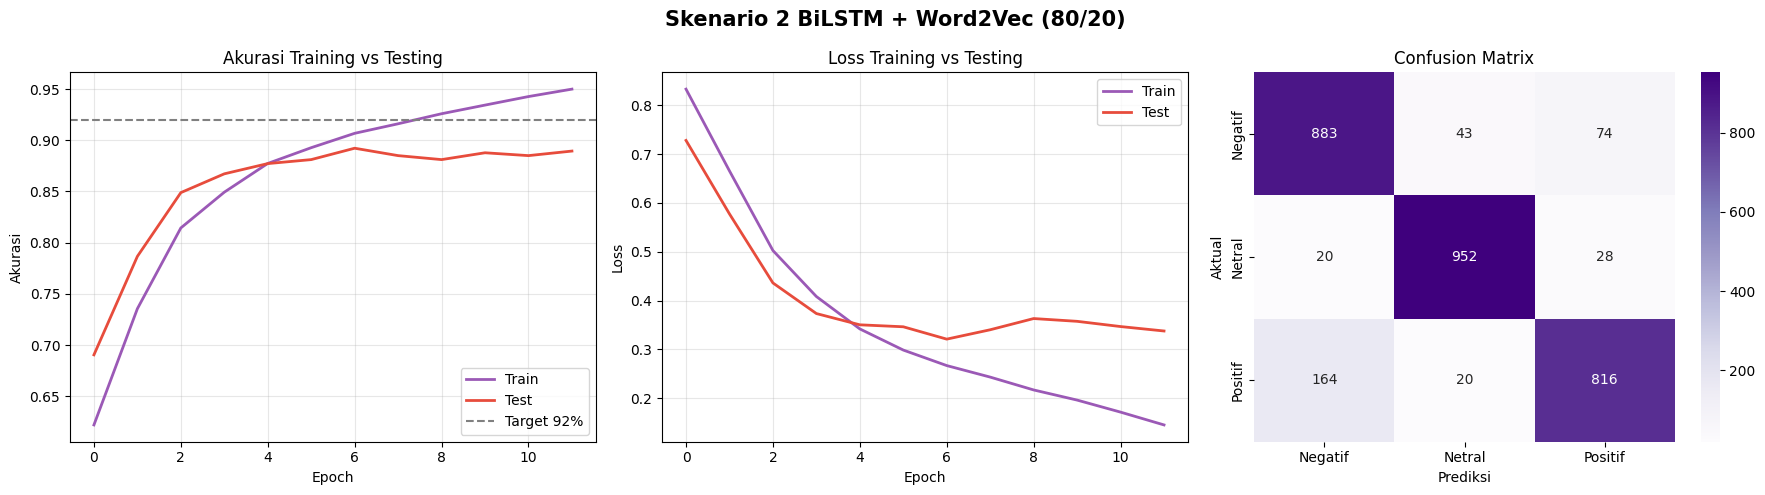

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Skenario 2 BiLSTM + Word2Vec (80/20)', fontsize=15, fontweight='bold')

axes[0].plot(history.history['accuracy'],     label='Train', color='#9b59b6', lw=2)
axes[0].plot(history.history['val_accuracy'], label='Test',  color='#e74c3c', lw=2)
axes[0].axhline(0.92, color='gray', linestyle='--', label='Target 92%')
axes[0].set_title('Akurasi Training vs Testing'); axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Akurasi'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(history.history['loss'],     label='Train', color='#9b59b6', lw=2)
axes[1].plot(history.history['val_loss'], label='Test',  color='#e74c3c', lw=2)
axes[1].set_title('Loss Training vs Testing'); axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss'); axes[1].legend(); axes[1].grid(alpha=0.3)

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', ax=axes[2],
            xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES)
axes[2].set_title('Confusion Matrix')
axes[2].set_ylabel('Aktual'); axes[2].set_xlabel('Prediksi')

plt.tight_layout()
plt.show()

In [12]:
results_s2 = {
    'scheme': 'Skema 2',
    'algorithm': 'BiLSTM',
    'feature': 'Word2Vec',
    'split': '80/20',
    'train_acc': round(train_acc*100,2),
    'test_acc': round(test_acc*100,2),
    'f1_macro': round(f1_score(y_test, y_pred, average='macro')*100,2)
}
with open('reports/scheme2_results.json', 'w') as f:
    json.dump(results_s2, f, indent=2)